In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation
from sklearn.datasets import make_classification, make_gaussian_quantiles

In [2]:
import warnings; warnings.simplefilter('ignore')

In [3]:
NUM_SAMPLES = 10
NUM_FEATURES = 20
NUM_CLIENTS = 50
NUM_CLUSTERS = 2

## Synthetic classification Dataset



We generate a two synthetic classification dataset using `make_classification`, ensuring a structured distribution of informative, redundant, and random features. These two datasets then work as pima dataset and cancer dataset as in [this notebook](https://github.com/sahelyiyi/FederatedLearning/blob/chain/experiments/nonparametric_experiment-different-models.ipynb).

#### 1. Number of Samples
The total number of samples \( N \) is:  

$
N = \frac{\text{num\_clients\_per\_cluster} \times \text{num\_training\_samples}}{0.7}
$

This ensures that **70%** of the data is allocated for training.

#### 2. Feature Distribution
Each sample has \( d \) features, categorized as:  

- **Informative features**:  
  $
  d_{\text{inf}} = 0.6 \times d
  $  
  (Directly impact classification).  

- **Redundant features**:  
  $
  d_{\text{red}} = 0.2 \times d
  $  
  (Linear combinations of informative features).  

- **Random features**:  
  $
  d_{\text{rand}} = d - (d_{\text{inf}} + d_{\text{red}})
  $  
  (Noisy, unrelated to classification).  

#### 3. Classes and Label Noise
- The dataset has \( C \) classes, where each sample belongs to one of them.  
- Label noise is controlled by:  
  $
  P(y' \neq y) = \text{flip\_y}
  $  
  which determines the probability of mislabeling a sample.

#### 4. Reproducibility**  
A fixed random seed (**42**) ensures consistent dataset generation across different runs.

This approach creates a **structured yet challenging classification dataset** with noise and feature dependencies.


## Create the graph data

Here we have a test dataset that is a comobination of the text datasets from both the first and second datasets mentioned above. Additionally, the features for each node of a graph is a random combination of these two datasets. For each node $i$, we first select a random number $r \in [15, 85]$ and then we randomly select $r$% of the the first dataset and $(100-r)$% of the second dataset as the train dataset for the node $i$.

Finally, the similarity score between nodes $i$ and $j$ is calculated based on the number of similar datapoint that they have in their training sets.

In [62]:
def get_graph(
        num_clients=NUM_CLIENTS, 
        num_features=NUM_FEATURES, 
        num_training_samples=NUM_SAMPLES, 
        num_clusters=NUM_CLUSTERS,
        n_classes=2, 
        noise=0.1,
    ):

    num_clients_per_cluster = num_clients//2
    # load Pima dataset
    c1_X, c1_y = make_classification(
            n_samples=int(num_clients_per_cluster*num_training_samples/0.7),
            n_features=num_features,
            n_informative=int(num_features * 0.6),  # 60% informative features
            n_redundant=int(num_features * 0.2),  # 20% redundant features
            n_classes=n_classes,
            flip_y=noise,  # Introduce label noise
            # weights=[0.3, 0.7],  # Imbalance classes
            random_state=42
        )
    c1_X = pd.DataFrame(c1_X)
    c1_y = pd.Series(c1_y)
            
    # load cancer dataset
    c2_X, c2_y = make_classification(
            n_samples=int(num_clients_per_cluster*num_training_samples/0.7),
            n_features=num_features,
            # n_informative=int(num_features * 0.6),  # 60% informative features
            # n_redundant=int(num_features * 0.2),  # 20% redundant features
            n_classes=n_classes,
            flip_y=noise,  # Introduce label noise
            random_state=42
        )
    
    c2_X = pd.DataFrame(c2_X)
    c2_y= pd.Series(c2_y)
    
    c2_y = c2_y.replace(0, 2)
    c2_y = c2_y.replace(1, 3)
    
    # split the pima dataset to train and test datasets
    c1_X_train, c1_X_test, c1_y_train, c1_y_test = train_test_split(
        c1_X, c1_y, test_size=0.3, random_state=1) # 70% training and 30% test

    # split the cancer dataset to train and test datasets
    c2_X_train, c2_X_test, c2_y_train, c2_y_test = train_test_split(
        c2_X, c2_y, test_size=0.3, random_state=1) # 70% training and 30% test    
    
    
    # combine the pima and cancer test datasets
    X_test = pd.concat((c1_X_test, c2_X_test))
    y_test = pd.concat((c1_y_test, c2_y_test))
    

    # 
    data_len = len(c1_X_train)
    datapoints = {}
    N = 20
    node_indices = []
    for n in range(N):
        # select a random number  0.25 < r < 0.75
        r = random.random()
        while r < 0.15 or r > 0.85:
            r = random.random()
            
        # uniformly select r% of the data from pima dataset
        node_idx1 = random.sample([i for i in range(data_len)], int(data_len*r)) 
        node_c1_X = c1_X_train.iloc[node_idx1]
        node_c1_y = c1_y_train.iloc[node_idx1].values
        
        # uniformly select (1-r)% of the data from cancer dataset
        node_idx2 = random.sample([i for i in range(data_len)], int(data_len*(1-r))) 
        node_c2_X = c2_X_train.iloc[node_idx2]
        node_c2_y = c2_y_train.iloc[node_idx2].values
        
        
        node_indices.append((node_idx1, node_idx2))
        datapoints[n] = {
            'features': pd.concat((node_c1_X, node_c2_X)),
            'all_features': pd.concat((node_c1_X, node_c2_X)),
            'labels': np.concatenate((node_c1_y, node_c2_y)),
            'all_labels': np.concatenate((node_c1_y, node_c2_y)),
            'sample_weights': np.ones(len(node_idx1)+len(node_idx2)),
            'model': DecisionTreeClassifier(),
        }

        
    # calculate the similarities between nodes
    E = N * (N-1)//2
    B = np.zeros((E, N))
    weight_vec = np.zeros(E)
    cnt = 0
    for i in range(N):
        for j in range(N):
            if j <= i:
                continue
            data_len = len(node_indices[i][0]) + len(node_indices[i][1])
#             w1 = len(node_indices[i][0]) - len(set(node_indices[i][0]) - set(node_indices[j][0]))
#             w2 = len(node_indices[i][1]) - len(set(node_indices[i][1]) - set(node_indices[j][1]))
            
            w1 = min(len(node_indices[i][0]), len(node_indices[j][0]))
            w2 = min(len(node_indices[i][1]), len(node_indices[j][1]))
            weight_vec[cnt] = (w1 + w2)/data_len
            B[cnt, i] = 1
            B[cnt, j] = -1
            cnt += 1
            
    return B, weight_vec, datapoints, X_test, y_test

            


## Algorithm


In [63]:
def algorithm(B, weight_vec, datapoints, X_test, y_test, lambda_lasso=1.0, K=100):
    test_len = len(X_test)
    
    iter_scores = []
    for k in range(K):
        
        # fit the model for each node
        for node in datapoints:
            clf = datapoints[node]['model']
            clf = clf.fit(datapoints[node]['all_features'], datapoints[node]['all_labels'], 
#                           sample_weight=datapoints[node]['sample_weights']
                         )
            datapoints[node]['model'] = clf

        # calculate the accuracy for each node
        accs = []
        for node in datapoints:
            clf = datapoints[node]['model']
            y_pred = clf.predict(X_test)
            accs.append(metrics.accuracy_score(y_test, y_pred))
        iter_scores.append(accs)

        # combine the test predictions for the adjancents node of each node
        for node in datapoints:
            datapoints[node]['all_features'] = [datapoints[node]['features']]
            datapoints[node]['all_labels'] = datapoints[node]['labels']
            datapoints[node]['sample_weights'] = np.ones(len(datapoints[node]['labels']))
            for B_neigh in np.where(B[:, node] != 0)[0]:
                w = weight_vec[B_neigh]
                for neigh in np.where(B[B_neigh, :] != 0)[0]:
                    if neigh == node:
                        continue
                    data_idx = random.sample([i for i in range(test_len)], int(test_len*w)) 
                    selected_x_test = X_test.iloc[data_idx]
                    datapoints[node]['all_features'].append(selected_x_test)
                    y_pred = datapoints[neigh]['model'].predict(selected_x_test)
                    datapoints[node]['all_labels'] = np.concatenate(
                        (datapoints[node]['all_labels'], y_pred))
                    _sample_weights = [lambda_lasso/2.0 for _ in range(len(y_pred))]
                    datapoints[node]['sample_weights'] = np.concatenate(
                        (datapoints[node]['sample_weights'], _sample_weights))

            datapoints[node]['all_features'] = pd.concat(datapoints[node]['all_features'])

    iter_scores = np.array(iter_scores)
    
    return iter_scores

In [64]:
B, weight_vec, datapoints, X_test, y_test = get_graph()

E, N = B.shape

K = 50
# federated learning accuracies
iter_scores = algorithm(B, weight_vec, datapoints, X_test, y_test, K=K)

# Individual accuracies
for node in datapoints:
    model = LogisticRegression(multi_class='multinomial')
    if node < N//2:
        model = DecisionTreeClassifier()
    datapoints[node]['model'] = model

single_iter_scores = []
for k in range(K):
    for node in datapoints:
        clf = datapoints[node]['model']
        clf = clf.fit(datapoints[node]['features'], datapoints[node]['labels'])
        datapoints[node]['model'] = clf
        
    accs = []
    for node in datapoints:
        clf = datapoints[node]['model']
        y_pred = clf.predict(X_test)
        accs.append(metrics.accuracy_score(y_test, y_pred))
    single_iter_scores.append(accs)
    
    
single_iter_scores = np.array(single_iter_scores)


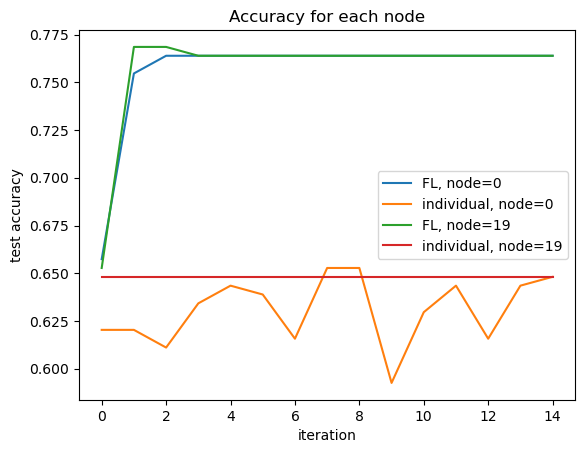

In [65]:
f = plt.figure()
x = [i for i in range(K)]
x = [i for i in range(15)]
for node in [0, 19]:
    plt.plot(x, iter_scores[:, node][:len(x)], label='FL, node=' + str(node))
    plt.plot(x, single_iter_scores[:, node][:len(x)], label='individual, node=' + str(node))

plt.title('Accuracy for each node')
plt.xlabel('iteration')
plt.ylabel('test accuracy')
# plt.yscale("log")
plt.legend()
plt.show()
plt.close()

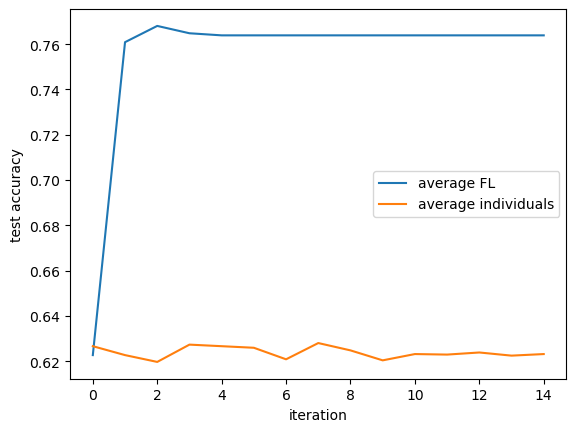

In [66]:
f = plt.figure()
x = [i for i in range(K)]
x = [i for i in range(15)]
fl_mean_acc = np.mean(iter_scores, axis=1)[:len(x)]
single_mean_acc = np.mean(single_iter_scores, axis=1)[:len(x)]
plt.plot(x, fl_mean_acc, label='average FL')
plt.plot(x, single_mean_acc, label='average individuals')

# plt.title('Mean accuracy for all the nodes')
plt.xlabel('iteration')
plt.ylabel('test accuracy')
# plt.yscale("log")
plt.legend()
plt.show()
try:
    f.savefig("../data/non-parametric/sythetic_cluster_different_fl_vs_individual.pdf", bbox_inches='tight')
except:
    os.makedirs("../data/non-parametric/", exist_ok=True)
    f.savefig("../data/non-parametric/sythetic_cluster_different_fl_vs_individual.pdf", bbox_inches='tight')
plt.close()

In [67]:
import json

fl_vs_individual_data = {
    'fl_sythetic_mean_acc': list(fl_mean_acc),
    'individual_mean_acc': list(single_mean_acc),
}

import pandas as pd
  
data = [[i, fl_mean_acc[i], single_mean_acc[i]] for i in range(15)]
  
# Create the pandas DataFrame
df = pd.DataFrame(data, columns=['iter', 'fl_mean', 'individual_mean'])

with open('../data/non-parametric/sythetic_cluster_different_fl_vs_individual.json', 'w') as f:
    f.write(json.dumps(fl_vs_individual_data))
    
df.to_csv('../data/non-parametric/sythetic_cluster_different_fl_vs_individual.csv')